# Label mechanism and positive ratio


In [35]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from load_experiment import load_experiment_results 
import datetime 
from helpers import get_n_labels


In [36]:
EXPERIMENT = "label_mechanism_positive_ratio"
VAR_1 = "label_mechanism"
VAR_2 = "positive_ratio"

In [37]:
df = load_experiment_results(name=EXPERIMENT)
df = df[df["model"]!="oracle"]
df.columns

Index(['label_mechanism', 'positive_ratio', 'dataset', 'iter', 'model',
       'accuracy', '0 precision', '1 precision', '0 recall', '1 recall',
       '0 f1', '1 f1', '0 support', '1 support', 'c log'],
      dtype='object')

In [38]:
df["precision"] = (df["0 precision"]+df["1 precision"]) / 2
df["recall"] = (df["0 recall"]+df["1 recall"]) / 2
df["f1"] = (df["0 f1"]+df["1 f1"]) / 2

df[["precision","recall","f1"]] = df[["precision","recall","f1"]].round(4)
df[["precision","recall","f1"]].describe()

,precision,recall,f1
count,4200.000000,4200.000000,4200.000000
mean,0.540718,0.549580,0.484210
std,0.274521,0.216379,0.237153
min,0.000000,0.000000,0.000000
25%,0.300000,0.500000,0.341700
50%,0.642050,0.526300,0.437800
75%,0.751125,0.660450,0.654375
max,0.973300,0.970800,0.971500


In [39]:
fig_experiment_folder = EXPERIMENT
os.makedirs(fig_experiment_folder, exist_ok=True)
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
fig_folder = os.path.join(fig_experiment_folder, f"{current_time}")
os.makedirs(fig_folder, exist_ok=True)

In [40]:
df["c log"].unique()

array([0.183, 0.   , 0.169, 0.177, 0.262, 0.192, 0.223, 0.246, 0.154,
       0.208, 0.259, 0.222, 0.204, 0.315, 0.167, 0.119, 0.19 , 0.238,
       0.143, 0.207, 0.211, 0.193, 0.186, 0.194, 0.212, 0.198, 0.206])

In [41]:
df.columns

Index(['label_mechanism', 'positive_ratio', 'dataset', 'iter', 'model',
       'accuracy', '0 precision', '1 precision', '0 recall', '1 recall',
       '0 f1', '1 f1', '0 support', '1 support', 'c log', 'precision',
       'recall', 'f1'],
      dtype='object')

In [42]:
experiments = df[VAR_1].unique()
experiments = [val for val in experiments if val.split("_")[1] == "1"]
df_exp = df[df[VAR_1].isin(experiments)]
df = df_exp


In [43]:
group_columns = [VAR_1, VAR_2, "model","dataset"]
data_G = df.groupby(group_columns).mean().reset_index()
data_G


,label_mechanism,positive_ratio,model,dataset,iter,accuracy,0 precision,1 precision,0 recall,1 recall,0 f1,1 f1,0 support,1 support,c log,precision,recall,f1
0,SAR_1_100,0.1,classic,breastcancer,4.5,0.522619,0.512935,0.292308,0.990476,0.054762,0.675437,0.089913,42.0,42.0,0.000,0.40262,0.52262,0.38266
1,SAR_1_100,0.1,classic,diabetes,4.5,0.671429,0.670356,0.650244,0.975000,0.109259,0.794135,0.177860,100.0,54.0,0.000,0.66029,0.54213,0.48599
2,SAR_1_100,0.1,classic,mnist,4.5,0.527650,0.523837,0.340694,0.998945,0.019114,0.687134,0.034742,1481.5,1373.0,0.000,0.43228,0.50903,0.36093
3,SAR_1_100,0.1,classic,mock,4.5,0.600305,0.600245,0.200000,0.999487,0.001538,0.750046,0.003053,195.0,130.0,0.000,0.40012,0.50050,0.37655
4,SAR_1_100,0.1,naive,breastcancer,4.5,0.554762,0.590681,0.550783,0.471429,0.638095,0.509637,0.583674,42.0,42.0,0.000,0.57073,0.55476,0.54666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,SCAR_1_1,0.5,naive,mock,4.5,0.400309,0.100000,0.400125,0.000513,1.000000,0.001020,0.571556,195.0,130.0,0.183,0.25006,0.50026,0.28627
296,SCAR_1_1,0.5,two_model,breastcancer,4.5,0.879762,0.817152,0.981434,0.985714,0.773810,0.892540,0.863125,42.0,42.0,0.183,0.89930,0.87976,0.87783
297,SCAR_1_1,0.5,two_model,diabetes,4.5,0.662338,0.829223,0.520619,0.614000,0.751852,0.696541,0.608661,100.0,54.0,0.183,0.67493,0.68293,0.65259
298,SCAR_1_1,0.5,two_model,mnist,4.5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000,0.00000,0.00000,0.00000


<Figure size 800x600 with 0 Axes>

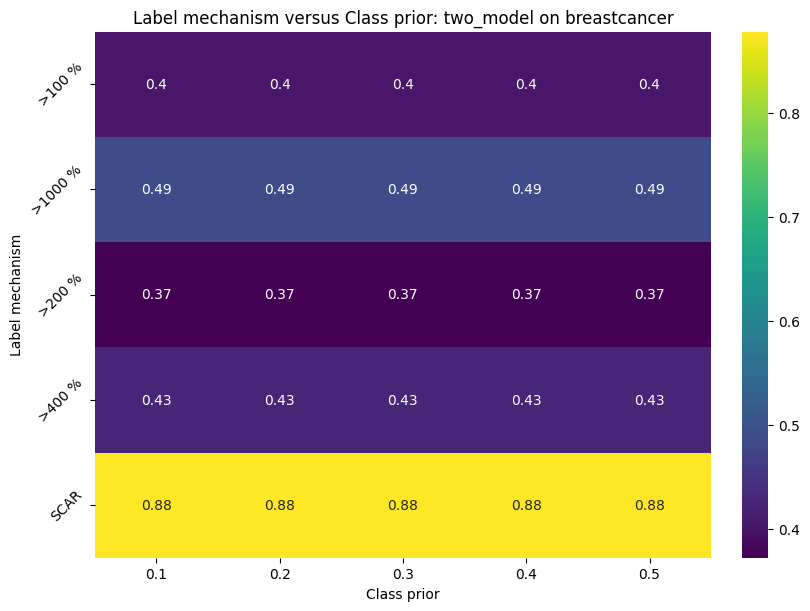

<Figure size 800x600 with 0 Axes>

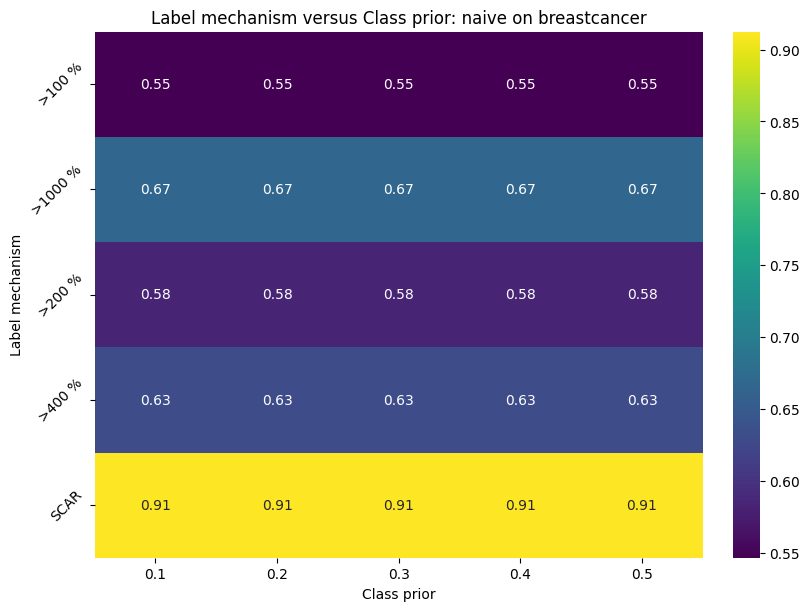

<Figure size 800x600 with 0 Axes>

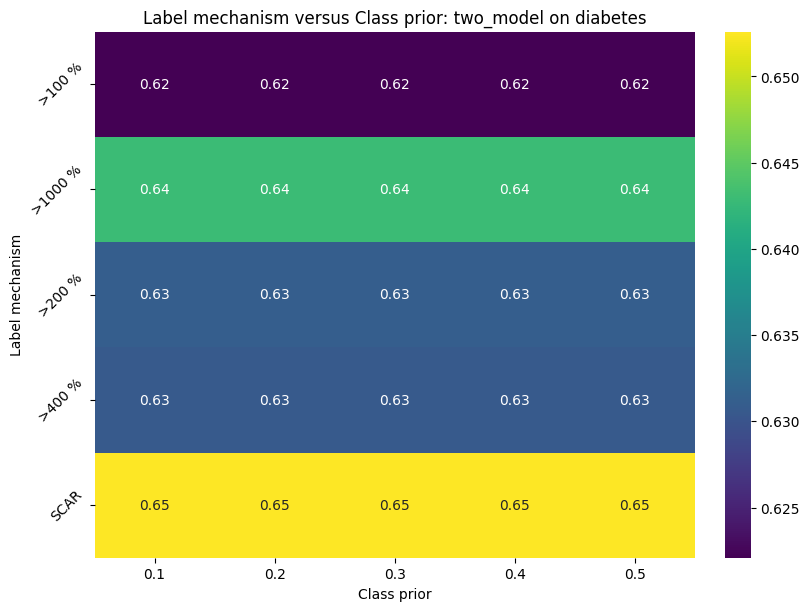

<Figure size 800x600 with 0 Axes>

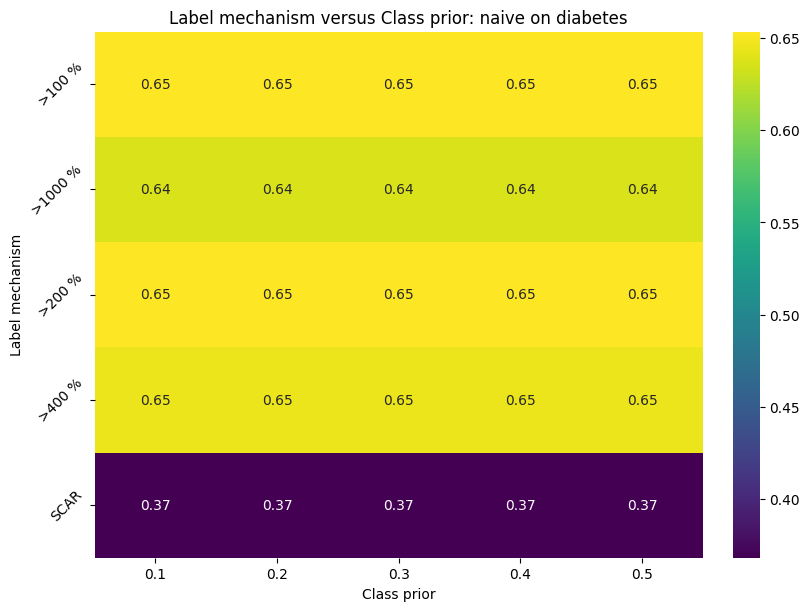

<Figure size 800x600 with 0 Axes>

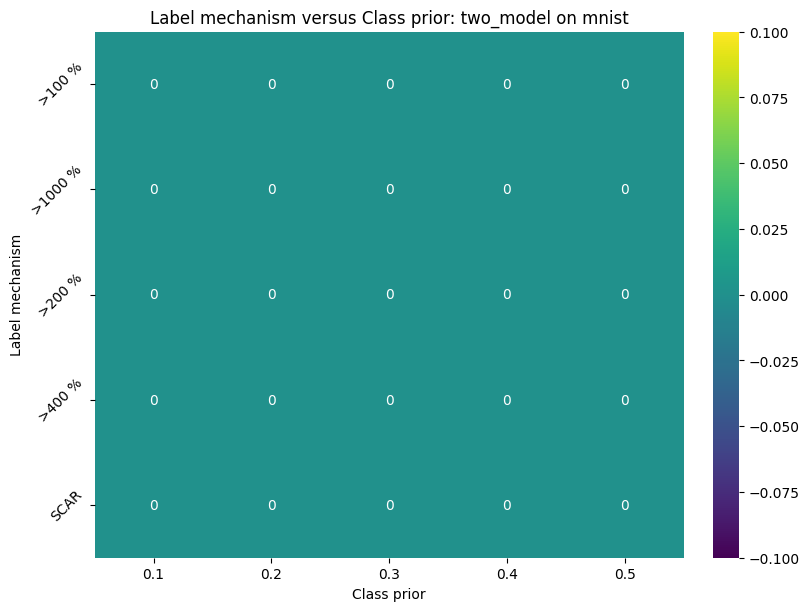

<Figure size 800x600 with 0 Axes>

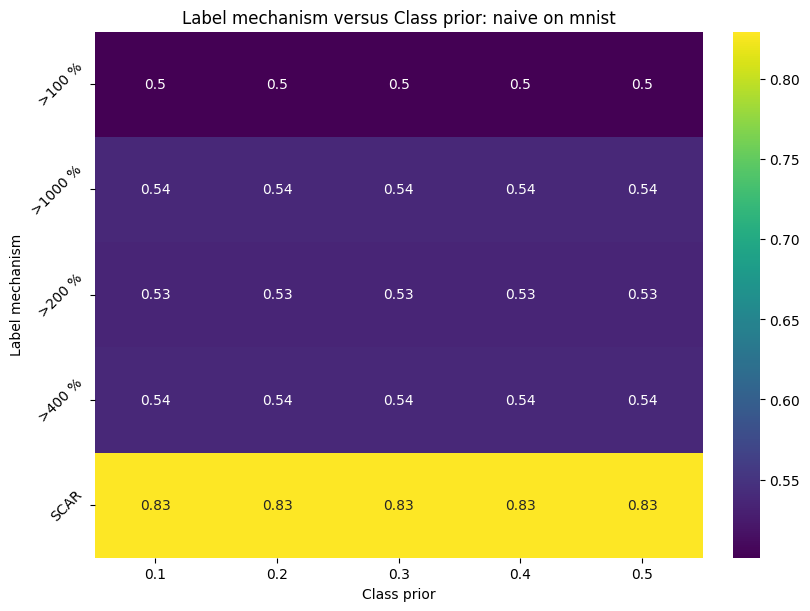

<Figure size 800x600 with 0 Axes>

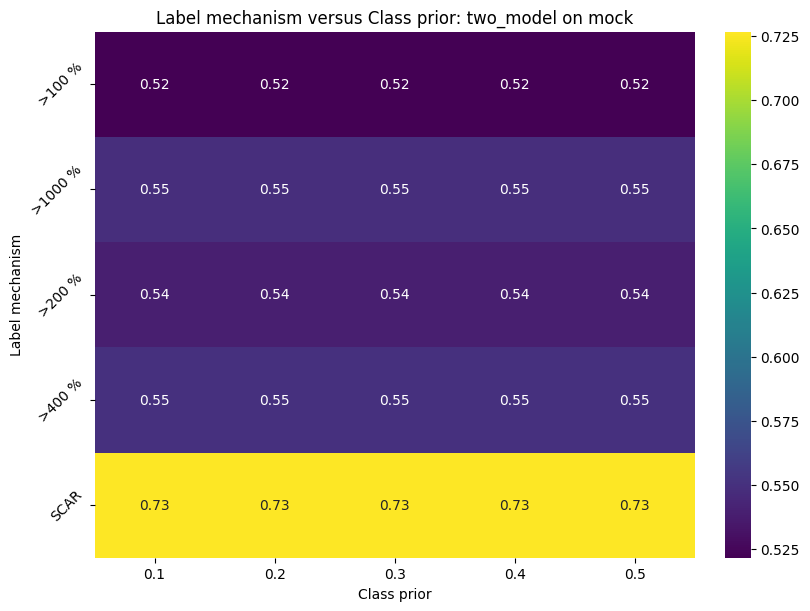

<Figure size 800x600 with 0 Axes>

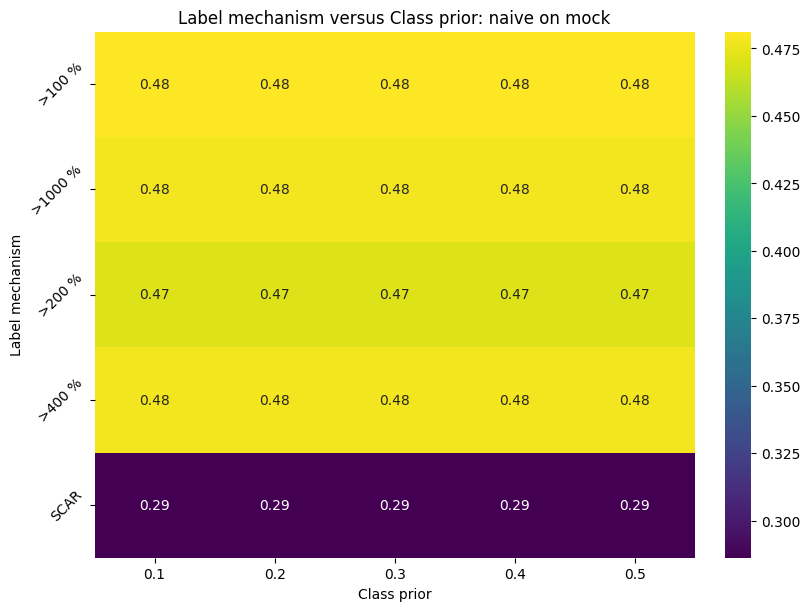

In [84]:
for dataset in data_G["dataset"].unique():
    data = data_G.loc[data_G['dataset']==dataset]
    for model in ["two_model","naive"]:



        fig = plt.figure(figsize=(8, 6),layout='constrained')
        data_m = data.loc[data['model']==model]
        fig = plt.figure(figsize=(8, 6),layout='constrained')
        data_selec = data_m[[VAR_1,VAR_2,"f1"]]
        try:
            pivot = data_selec.pivot_table(index=VAR_1, columns=VAR_2, values="f1")
            plt.title(f"Label mechanism versus Class prior: {model} on {dataset}")
            sns.heatmap(data=pivot,annot=True,cmap="viridis")
            plt.xlabel("Class prior")
            plt.ylabel("Label mechanism")

            y_ticks = [f">{i.split('_')[-1]} %" for i in data_selec[VAR_1].unique() if i.startswith("SAR")]
            y_ticks.append("SCAR")
            # y_ticks.insert(-1, "SCAR")

            plt.yticks(ticks=np.arange(0,len(y_ticks),1)+0.5, labels=y_ticks, rotation=45)
            plt.savefig(os.path.join(fig_folder, f"{model}_{dataset}_heatmap_{VAR_1}_vs_{VAR_2}.png"))
            plt.show()
        except Exception as e:
            print(f"Error occurred while plotting heatmap for {model} on {dataset}: {e}")
